# Task 4: Regression — California Housing Prices

**Goal:** predict a continuous number (median house value) instead of a category — this is
regression, not classification. Dataset: California Housing (20,640 districts, 1990 census
data) — the standard sklearn/Kaggle-equivalent housing regression dataset, used here in place
of the deprecated Boston Housing dataset.


## 1. Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [3]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
# total_bedrooms has 207 missing values — fill with the median (robust to skew)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

Missing values:
 total_bedrooms    207
dtype: int64


## 2. Select features

Picking 5 features that intuitively should drive house price most directly:
- **median_income** — strongest real-world driver of what an area's homes are worth
- **total_rooms** — overall size/scale of housing stock in the district
- **housing_median_age** — older vs. newer housing stock
- **latitude** / **longitude** — location, location, location (coastal vs. inland California)

Target: **median_house_value**.


In [4]:
features = ['median_income', 'total_rooms', 'housing_median_age', 'latitude', 'longitude']
target = 'median_house_value'

X = df[features]
y = df[target]

X.describe()

,median_income,total_rooms,housing_median_age,latitude,longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,2635.763081,28.639486,35.631861,-119.569704
std,1.899822,2181.615252,12.585558,2.135952,2.003532
min,0.499900,2.000000,1.000000,32.540000,-124.350000
25%,2.563400,1447.750000,18.000000,33.930000,-121.800000
50%,3.534800,2127.000000,29.000000,34.260000,-118.490000
75%,4.743250,3148.000000,37.000000,37.710000,-118.010000
max,15.000100,39320.000000,52.000000,41.950000,-114.310000


## 3. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (16512, 5)  Test: (4128, 5)


## 4. Train Linear Regression model

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

coeffs = pd.Series(lr.coef_, index=features).sort_values(key=abs, ascending=False)
print("Feature coefficients (impact per unit increase):\n", coeffs)
print("\nIntercept:", lr.intercept_)

Feature coefficients (impact per unit increase):
 longitude            -44682.959059
latitude             -43887.440531
median_income         37535.980826
housing_median_age     1167.869663
total_rooms               3.383466
dtype: float64

Intercept: -3759827.101363705


## 5. Evaluate: RMSE and R²

In [7]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.2f}")
print(f"R²  : {r2:.4f}")

RMSE: $73,793.10
R²  : 0.5844


## 6. Predicted vs. actual scatter plot

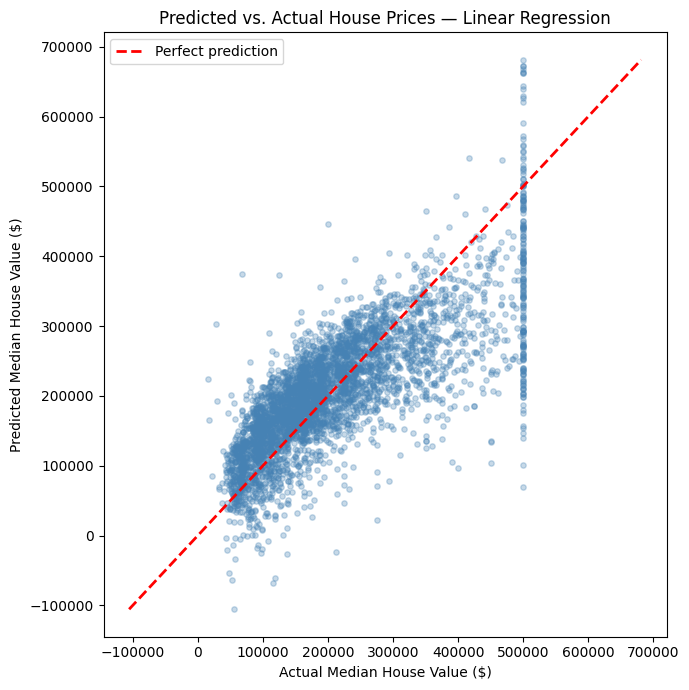

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual Median House Value ($)")
plt.ylabel("Predicted Median House Value ($)")
plt.title("Predicted vs. Actual House Prices — Linear Regression")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=100)
plt.show()

## 7. What does the R² score mean? (plain English)

Our model scored **R² = 0.58**, which means roughly 58% of the differences in house prices
across districts can be explained by the five features we chose (income, room count, age,
and location). In plain terms: if you gave this model income level, house age, room count,
and coordinates for a neighborhood, it could get you meaningfully closer to the real price
than a random guess — but it's still missing about 42% of the story, which likely comes down
to things we didn't include, like school quality, exact neighborhood desirability, or crime
rates. Looking at the scatter plot, points close to the red dashed line are districts the
model priced accurately, while points far above or below it are places the model over- or
under-priced. In short: this is a reasonable first estimate of home value, useful for a
ballpark figure, but not precise enough to replace a real appraisal.